# Intro

In [1]:
import pandas as pd
df = pd.read_csv("glovo_ops_data_final.csv")
df.head()

,order_id,customer_id,courier_id,store_address_id,store_name,vertical,gtv,delivery_fee,description,activation_time_local,...,pickup_time_local,delivery_time_local,tranport_type,rating,bad_rating_reason,pickup_latitude,pickup_longitude,delivery_latitude,delivery_longitude,saturation
0,32.0,700734,441.0,10887.0,Pharmacie,WALL - Partner,19.97,4.9,1 x DOLIPRANE 1000mg - 8 comprimés\n1 x IMODIU...,2019-10-01 09:21:34.000,...,2019-10-01 09:34:55.904,2019-10-01 09:50:02.000,MOTORBIKE,5.0,NaN,48.861046,2.275441,48.855068,2.283378,66
1,29.0,1648235,239.0,3705.0,Starbucks,WALL - NonPartner,10.50,4.9,"1 x Caffe Latte - Tall, Espresso Roast Class...",2019-10-01 09:18:30.000,...,2019-10-01 09:36:02.133,2019-10-01 09:47:39.000,BICYCLE,NaN,NaN,48.871578,2.304495,48.867017,2.292787,40
2,292.0,13527080,351.0,1035.0,Starbucks,WALL - NonPartner,10.35,4.9,Venti Latte Vanille Glace avec seulement 2 pom...,2019-10-01 15:04:50.000,...,2019-10-01 15:25:37.131,2019-10-01 15:34:52.000,MOTORBIKE,5.0,NaN,48.855461,2.360776,48.866713,2.364773,29
3,743.0,275173,391.0,NaN,NaN,COURIER,6.60,6.6,Lunettes,2019-10-02 10:08:38.000,...,2019-10-02 10:30:24.559,2019-10-02 10:50:13.000,MOTORBIKE,NaN,NaN,48.859665,2.285694,48.884335,2.259989,54
4,838.0,1105241,263.0,51106.0,Franprix,WALL - Partner,13.10,3.9,"1 x Emmental rape 29% - Franprix - 3x35g - 1,4...",2019-10-02 12:12:09.000,...,2019-10-02 12:31:21.010,2019-10-02 12:38:04.000,MOTORBIKE,5.0,NaN,48.863417,2.361240,48.868087,2.371050,77




**ESTIMATED TIME OF ARRIVAL**

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63646 entries, 0 to 63645
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   order_id                     63646 non-null  float64
 1   customer_id                  63646 non-null  int64  
 2   courier_id                   63646 non-null  float64
 3   store_address_id             52018 non-null  float64
 4   store_name                   52018 non-null  object 
 5   vertical                     63646 non-null  object 
 6   gtv                          63646 non-null  float64
 7   delivery_fee                 63646 non-null  float64
 8   description                  63614 non-null  object 
 9   activation_time_local        63646 non-null  object 
 10  courier_started_order_local  63642 non-null  object 
 11  pickup_time_local            63646 non-null  object 
 12  delivery_time_local          63646 non-null  object 
 13  tranport_type   

# EDA

## Variables tipo Object

Variables Object:
* Cuatro variables de tiempo:
  * **activation_time_local**
  * **courier_started_order_local**
  * **pickup_time_local**
  * **delivery_time_local**
* f

In [4]:
df.select_dtypes(include="object").head(3)

,store_name,vertical,description,activation_time_local,courier_started_order_local,pickup_time_local,delivery_time_local,tranport_type,bad_rating_reason
0,Pharmacie,WALL - Partner,1 x DOLIPRANE 1000mg - 8 comprimés\n1 x IMODIU...,2019-10-01 09:21:34.000,2019-10-01 09:19:06.342,2019-10-01 09:34:55.904,2019-10-01 09:50:02.000,MOTORBIKE,NaN
1,Starbucks,WALL - NonPartner,"1 x Caffe Latte - Tall, Espresso Roast Class...",2019-10-01 09:18:30.000,2019-10-01 09:28:04.560,2019-10-01 09:36:02.133,2019-10-01 09:47:39.000,BICYCLE,NaN
2,Starbucks,WALL - NonPartner,Venti Latte Vanille Glace avec seulement 2 pom...,2019-10-01 15:04:50.000,2019-10-01 15:04:28.032,2019-10-01 15:25:37.131,2019-10-01 15:34:52.000,MOTORBIKE,NaN


In [5]:
object_var = ["tranport_type","vertical"]

for i in object_var:
  print(df[i].unique())

['MOTORBIKE' 'BICYCLE' 'CAR' 'WALKER']
['WALL - Partner' 'WALL - NonPartner' 'COURIER']


## Variables tipo numerical

* **Order_id** eliminada
* **Customer_id** eliminada
* **"delivery_time_local","pickup_time_local","activation_time_local","courier_started_order_local"** Timestamps del recorreido del pedido, variable(s) objetivo


In [6]:
df.select_dtypes(include=["float","int"]).head(3)

,order_id,customer_id,courier_id,store_address_id,gtv,delivery_fee,rating,pickup_latitude,pickup_longitude,delivery_latitude,delivery_longitude,saturation
0,32.0,700734,441.0,10887.0,19.97,4.9,5.0,48.861046,2.275441,48.855068,2.283378,66
1,29.0,1648235,239.0,3705.0,10.50,4.9,NaN,48.871578,2.304495,48.867017,2.292787,40
2,292.0,13527080,351.0,1035.0,10.35,4.9,5.0,48.855461,2.360776,48.866713,2.364773,29


In [7]:
df.select_dtypes(include=["float","int"]).describe()

,order_id,customer_id,courier_id,store_address_id,gtv,delivery_fee,rating,pickup_latitude,pickup_longitude,delivery_latitude,delivery_longitude,saturation
count,63646.000000,6.364600e+04,63646.000000,52018.000000,63646.000000,63646.000000,26784.000000,63646.000000,63646.000000,63646.000000,63646.000000,63646.000000
mean,42599.441033,7.339444e+06,281.304183,42794.678477,23.475663,5.569971,4.820154,48.864058,2.321907,48.864130,2.318299,77.772633
std,24605.798877,8.219375e+06,140.223522,41522.426586,17.365952,3.661555,0.827880,0.017255,0.037469,0.020156,0.040682,36.107480
min,1.000000,1.154000e+03,1.000000,911.000000,0.000000,0.000000,1.000000,48.803918,2.221335,48.794007,2.211807,20.000000
25%,21298.250000,1.094467e+06,165.000000,7113.000000,12.900000,3.900000,5.000000,48.852065,2.289582,48.850450,2.287040,51.000000
50%,42649.500000,3.209173e+06,303.000000,23886.000000,18.390000,3.900000,5.000000,48.866397,2.322111,48.865338,2.314835,73.000000
75%,63922.750000,1.167532e+07,403.000000,78604.000000,28.500000,6.900000,5.000000,48.876436,2.349763,48.878739,2.348273,98.000000
max,85126.000000,2.986686e+07,534.000000,136345.000000,346.620000,23.900000,5.000000,48.916104,2.437825,48.928184,2.443143,239.000000


In [8]:
df.select_dtypes(include=['object']).columns

Index(['store_name', 'vertical', 'description', 'activation_time_local',
       'courier_started_order_local', 'pickup_time_local',
       'delivery_time_local', 'tranport_type', 'bad_rating_reason'],
      dtype='object')

/tmp/ipykernel_66200/3191384764.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.index, y=top_values.values, palette='viridis')
/tmp/ipykernel_66200/3191384764.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.index, y=top_values.values, palette='viridis')
/tmp/ipykernel_66200/3191384764.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values.index, y=top_values.values, palette='viridis')
/tmp/ipykernel_66200/3191384764.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated 

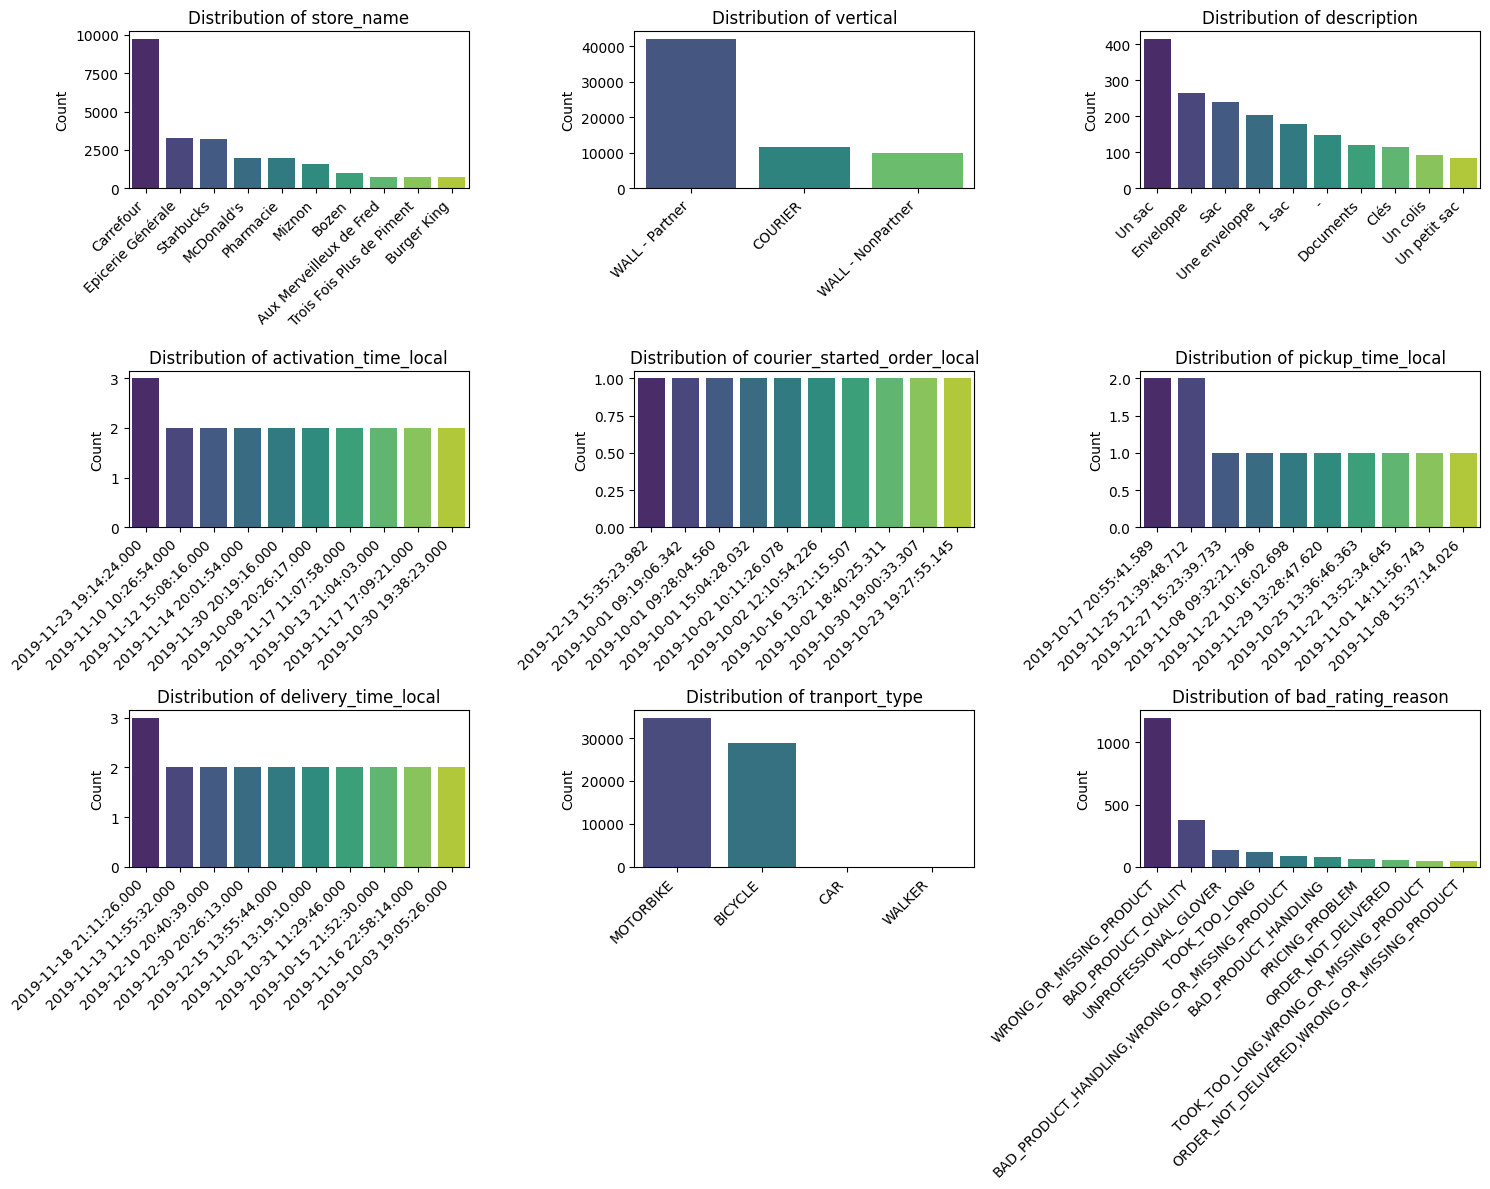

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns


# Get object type columns. This was previously identified.
object_columns = df.select_dtypes(include=['object']).columns.tolist()

# Determine the number of subplots and grid layout
n_cols = 3 # Number of columns for the subplot grid
n_rows = (len(object_columns) + n_cols - 1) // n_cols # Calculate rows needed

plt.figure(figsize=(n_cols * 5, n_rows * 4)) # Adjust figure size dynamically

for i, col in enumerate(object_columns):
    plt.subplot(n_rows, n_cols, i + 1)

    # Count value frequencies and take top N values (e.g., top 10)
    # This prevents overcrowded plots for columns with many unique values
    top_values = df[col].value_counts().nlargest(10)
    sns.barplot(x=top_values.index, y=top_values.values, palette='viridis')

    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel('') # Remove x-label as title is descriptive
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability

plt.tight_layout() # Adjust subplot params for a tight layout
plt.show()

### Fechas

ESTIMATED TIME OF ARRIVAL

Definición de la Variable Objetivo: Se crea delivery_time_minutes, que representa el tiempo total de ciclo del pedido. Al ser la variable que el modelo intentará predecir, se establece como el eje central del estudio.

In [10]:
# PROCESAMIENTO INICIAL (Necesario para el EDA)
df['activation_time_local'] = pd.to_datetime(df['activation_time_local'])
df['courier_started_order_local'] = pd.to_datetime(df['courier_started_order_local'])
df['pickup_time_local'] = pd.to_datetime(df['pickup_time_local'])
df['delivery_time_local'] = pd.to_datetime(df['delivery_time_local'])

# Crear variables para poder explorar en el EDA
df['delivery_time_minutes'] = (df['delivery_time_local'] - df['activation_time_local']).dt.total_seconds() / 60
df['hour_of_day'] = df['activation_time_local'].dt.hour
df['day_of_week'] = df['activation_time_local'].dt.dayofweek

¿Qué es el ETA y por qué es crítico?
El ETA (Estimated Time of Arrival) es el tiempo estimado de llegada. En el contexto de una plataforma como Glovo, representa la promesa de entrega que se le hace al usuario final.

Técnicamente, el ETA es el resultado de la suma de varios micro-tiempos:

Tiempo de Reacción: Desde la activación hasta que un repartidor acepta.

Tiempo de Preparación: Lo que tarda el establecimiento en tener el pedido listo.

Tiempo de Tránsito: El desplazamiento físico desde el punto A (tienda) al punto B (cliente).

In [11]:
df['delivery_time_minutes'].describe()

,delivery_time_minutes
count,63646.000000
mean,38.127949
std,15.639348
min,3.633333
25%,27.400000
50%,35.100000
75%,45.333333
max,136.600000


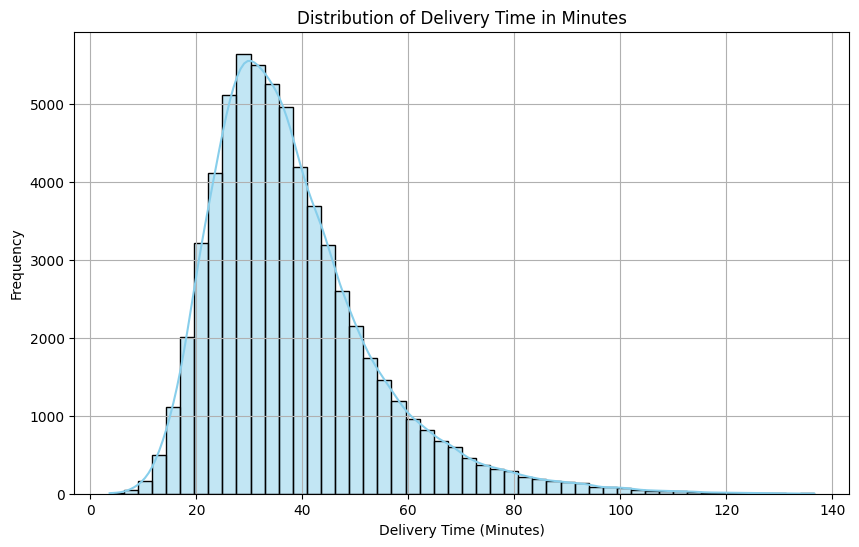

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df['delivery_time_minutes'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Delivery Time in Minutes')
plt.xlabel('Delivery Time (Minutes)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

/tmp/ipykernel_66200/4043450601.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='delivery_time_minutes', y=nombre_columna_transporte,


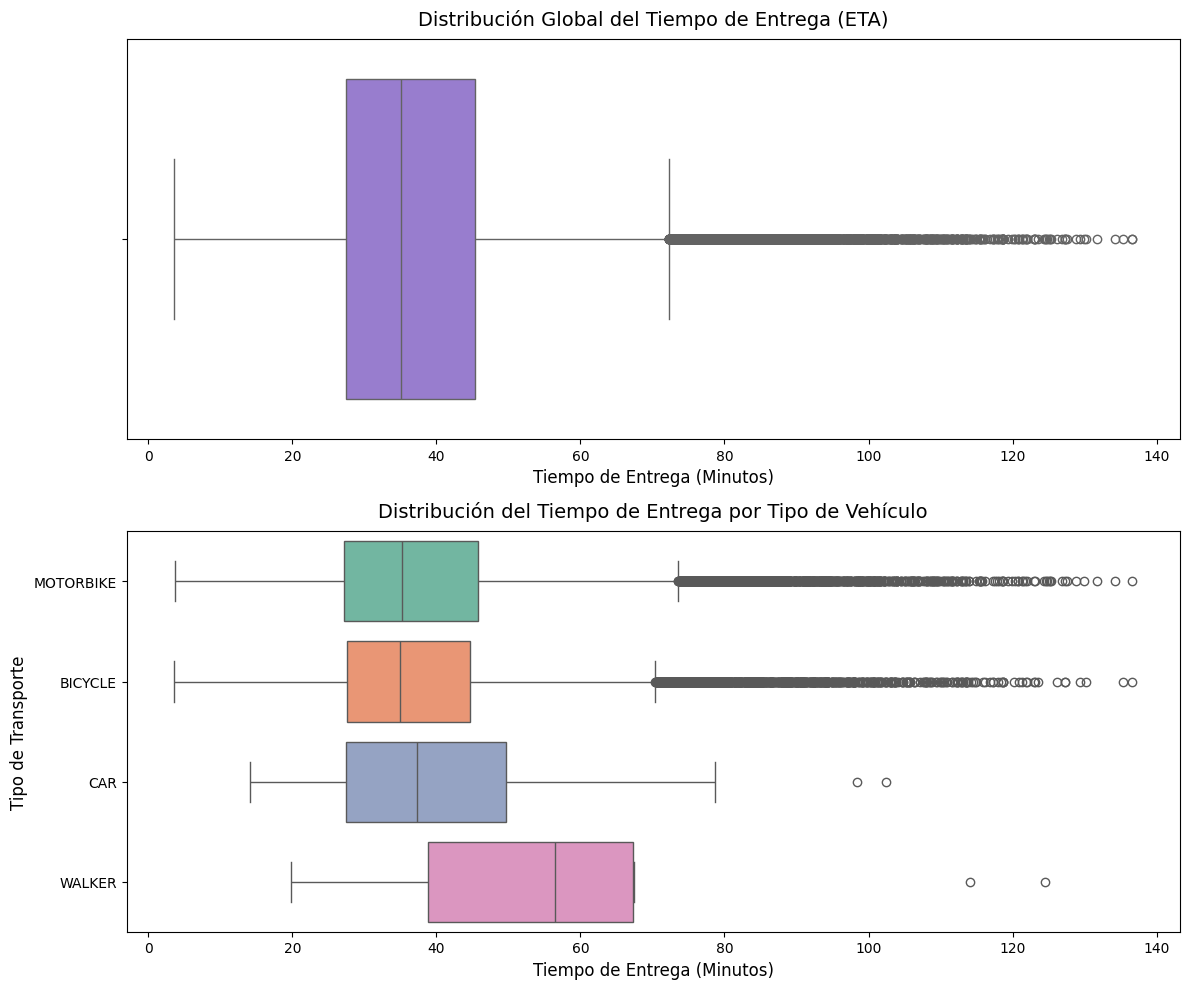

In [13]:
 #Crear una figura con dos subgráficos (uno arriba y otro abajo)
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# 1. Gráfico de Caja Global
sns.boxplot(data=df, x='delivery_time_minutes', color='mediumpurple', ax=axes[0])
axes[0].set_title('Distribución Global del Tiempo de Entrega (ETA)', fontsize=14, pad=10)
axes[0].set_xlabel('Tiempo de Entrega (Minutos)', fontsize=12)


# 2. Gráfico de Caja segmentado por Tipo de Transporte (si tienes la columna)
# Nota: Asegúrate de que la columna se llame 'transport_type' o 'tranport_type' según tu dataset
nombre_columna_transporte = 'tranport_type' # Ajusta esto si tu columna tiene otro nombre

if nombre_columna_transporte in df.columns:
    sns.boxplot(data=df, x='delivery_time_minutes', y=nombre_columna_transporte,
                palette='Set2', ax=axes[1])
    axes[1].set_title('Distribución del Tiempo de Entrega por Tipo de Vehículo', fontsize=14, pad=10)
    axes[1].set_xlabel('Tiempo de Entrega (Minutos)', fontsize=12)
    axes[1].set_ylabel('Tipo de Transporte', fontsize=12)
else:
    axes[1].set_visible(False) # Oculta el segundo gráfico si no existe la columna

plt.tight_layout()
plt.show()


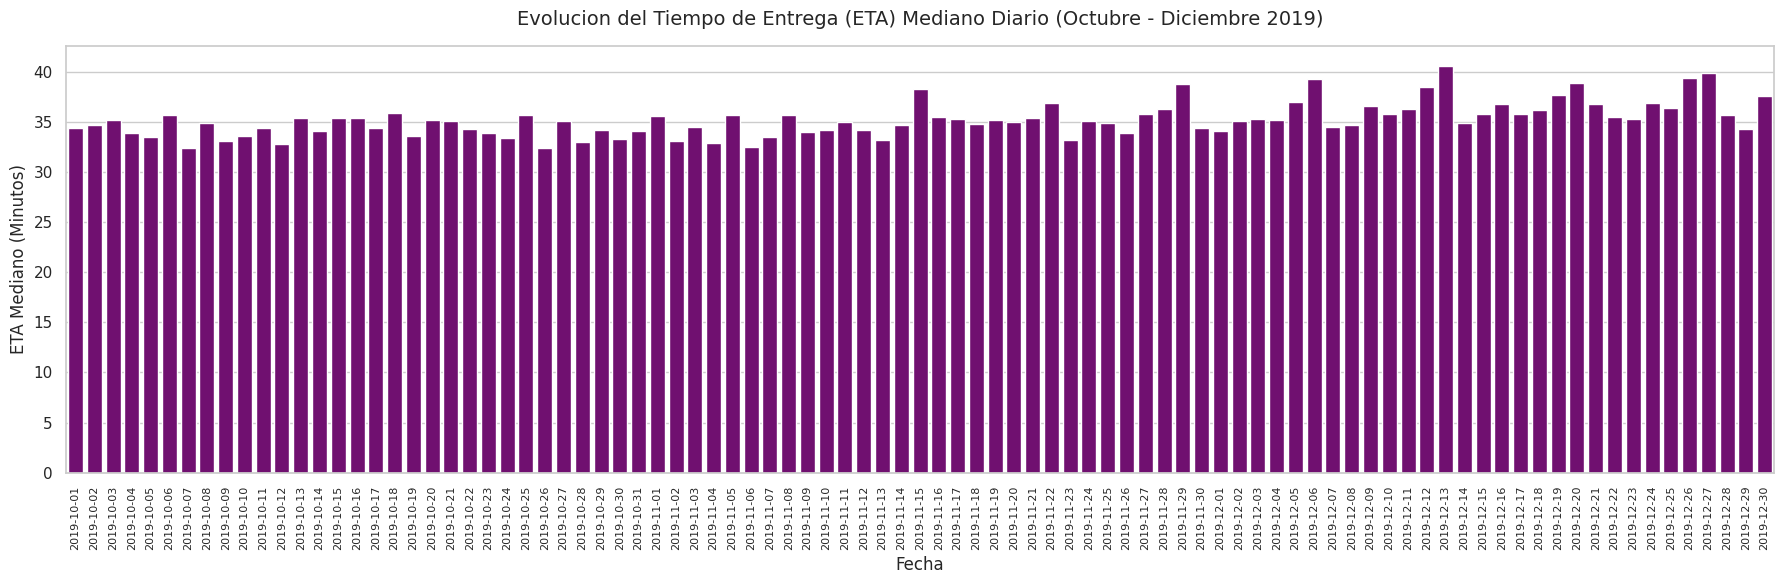

In [14]:
# Configurar el estilo visual
sns.set_theme(style="whitegrid")

# 1. Asegurarnos de tener la columna 'date'
df['date'] = df['activation_time_local'].dt.date

# 2. Asegurarnos de tener el tiempo de entrega en minutos
# Si utilizaste 'ETA_seconds' en el paso anterior, lo dividimos por 60.
if 'delivery_time_minutes' not in df.columns:
    df['delivery_time_minutes'] = df['ETA_seconds'] / 60

# 3. Agrupar y calcular el ETA (tiempo de entrega) MEDIANO por cada día
eta_por_dia = df.groupby('date')['delivery_time_minutes'].median().reset_index()

# 4. Crear el gráfico de barras (Barplot)
plt.figure(figsize=(18, 6))

# Utilizamos color morado para contrastar con los anteriores
sns.barplot(data=eta_por_dia, x='date', y='delivery_time_minutes', color='purple')

plt.title('Evolucion del Tiempo de Entrega (ETA) Mediano Diario (Octubre - Diciembre 2019)', fontsize=14, pad=15)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('ETA Mediano (Minutos)', fontsize=12)

# Rotar las fechas a 90 grados y reducir la fuente para facilitar la lectura
plt.xticks(rotation=90, fontsize=8)

plt.tight_layout()
plt.show()

Se observa una tendencia clara de crecimiento conforme avanza la semana. Mientras que el lunes y martes presentan los tiempos más ágiles, el viernes, sábado y domingo muestran los mayores tiempos de espera medianos.

## Análisis de la Saturación de Flota
En esta sección del EDA, analizamos la variable Saturación, que mide la relación entre la demanda de pedidos y la disponibilidad de repartidores en tiempo real. Entender este comportamiento es vital, ya que la saturación suele ser el principal cuello de botella que degrada la precisión del ETA.

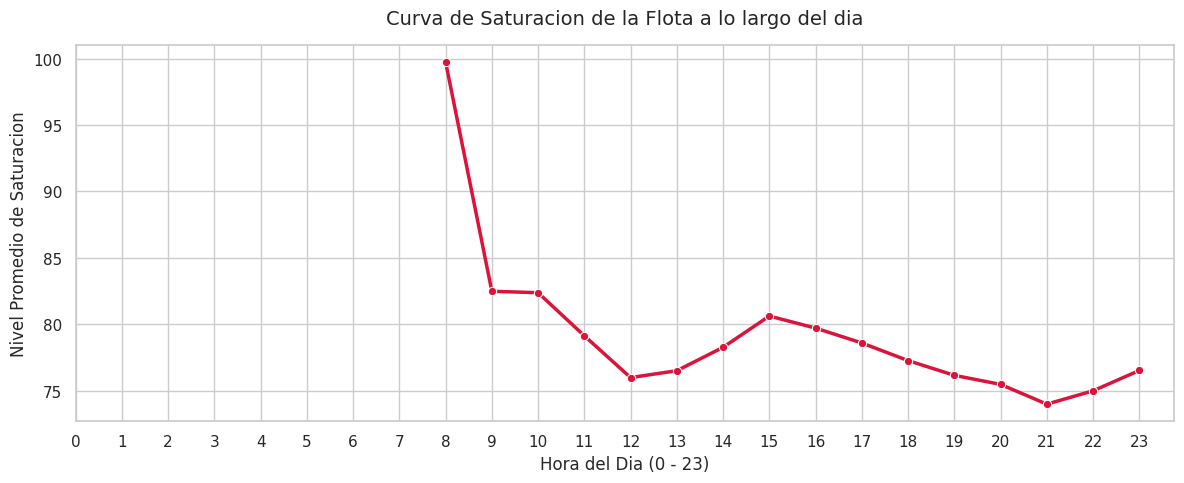

/tmp/ipykernel_66200/3230396815.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='day_of_week', y='saturation', palette='viridis', estimator=np.mean, errorbar=None)


<Figure size 1000x500 with 0 Axes>

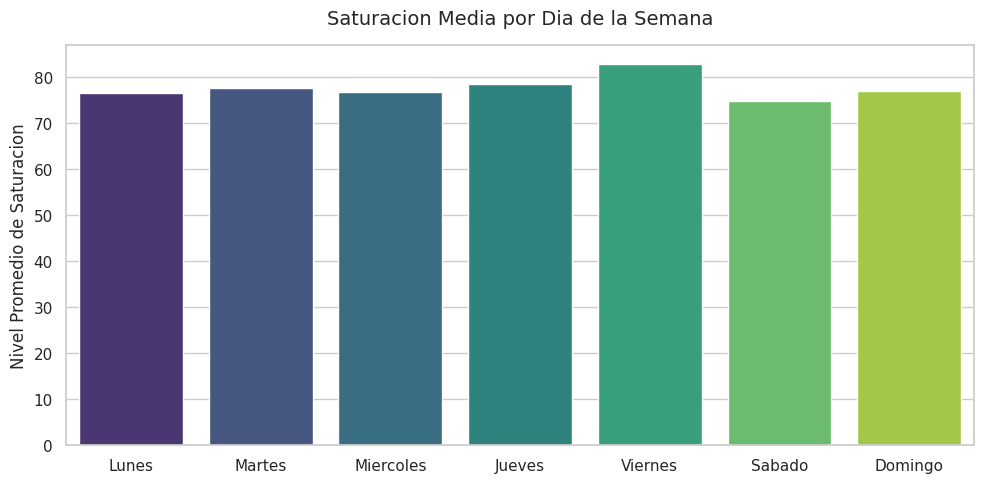

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo visual
sns.set_theme(style="whitegrid")

# Gráfico 1: Saturación promedio a lo largo de las 24 horas del día
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='hour_of_day', y='saturation', estimator='mean',
             errorbar=None, marker='o', linewidth=2.5, color='crimson')
plt.title('Curva de Saturacion de la Flota a lo largo del dia', fontsize=14, pad=15)
plt.xlabel('Hora del Dia (0 - 23)', fontsize=12)
plt.ylabel('Nivel Promedio de Saturacion', fontsize=12)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
dias_semana = ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo']

# Configuración visual
plt.figure(figsize=(10, 5))
dias_semana = ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo']

# Cambiamos np.median por np.mean para obtener el promedio
sns.barplot(data=df, x='day_of_week', y='saturation', palette='viridis', estimator=np.mean, errorbar=None)

plt.title('Saturacion Media por Dia de la Semana', fontsize=14, pad=15)
plt.xticks(ticks=range(7), labels=dias_semana)
plt.xlabel('')
plt.ylabel('Nivel Promedio de Saturacion', fontsize=12)
plt.tight_layout()
plt.show()

Al comparar la curva de saturación con el volumen de pedidos, se observa un fenómeno contraelectivo: aunque el volumen total de pedidos suele ser alto durante la cena, la saturación relativa tiende a ser menor o más estable que en el almuerzo

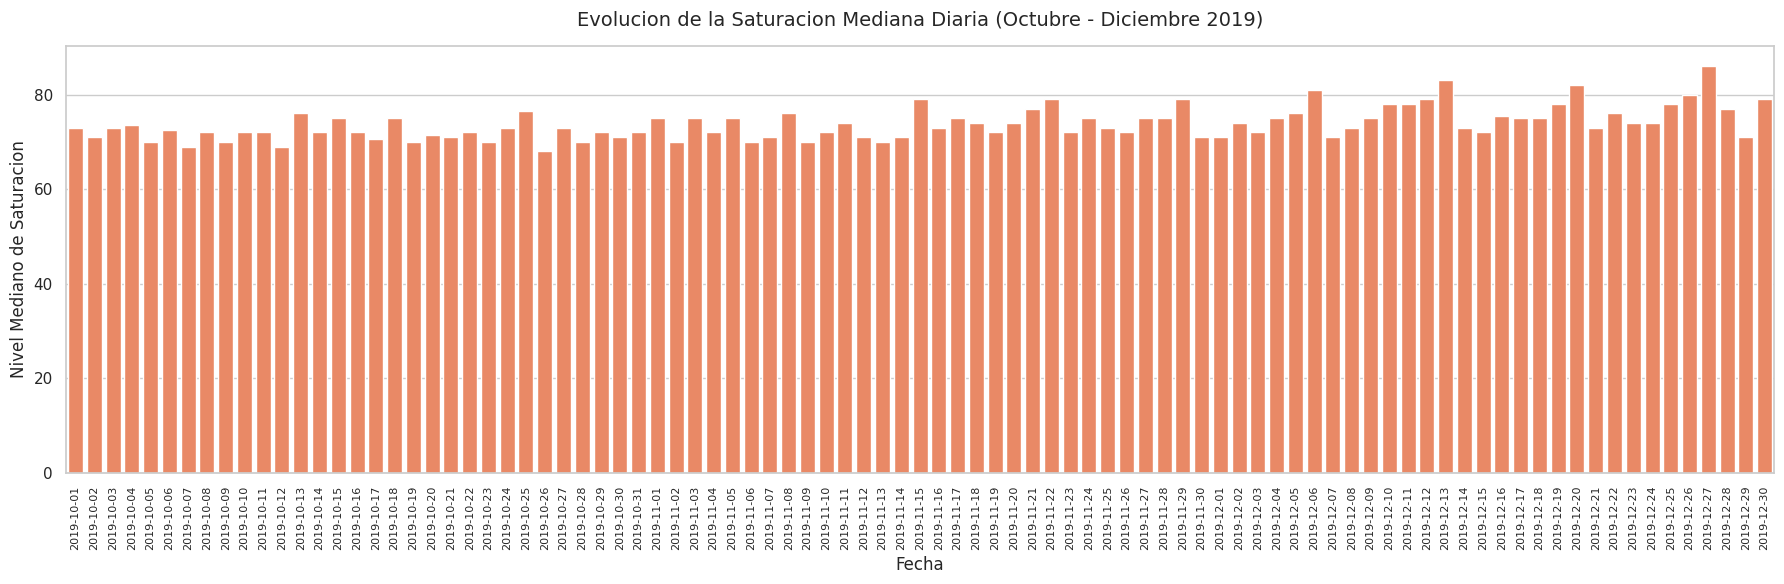

In [16]:
# 2. Agrupar y calcular la saturación MEDIANA por cada día exacto
saturacion_por_dia = df.groupby('date')['saturation'].median().reset_index()

# 3. Crear el gráfico de barras (Barplot)
plt.figure(figsize=(18, 6)) # Ampliamos el ancho para acomodar bien todos los días

# Usamos barplot manteniendo el color coral para diferenciarlo de los pedidos
sns.barplot(data=saturacion_por_dia, x='date', y='saturation', color='coral')

plt.title('Evolucion de la Saturacion Mediana Diaria (Octubre - Diciembre 2019)', fontsize=14, pad=15)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Nivel Mediano de Saturacion', fontsize=12)

# Rotar las fechas a 90 grados y reducir la fuente para facilitar la lectura
plt.xticks(rotation=90, fontsize=8)

plt.tight_layout()
plt.show()

## Volumen de pedidos

/tmp/ipykernel_66200/3357885963.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(data=df, x='day_of_week', palette='viridis')


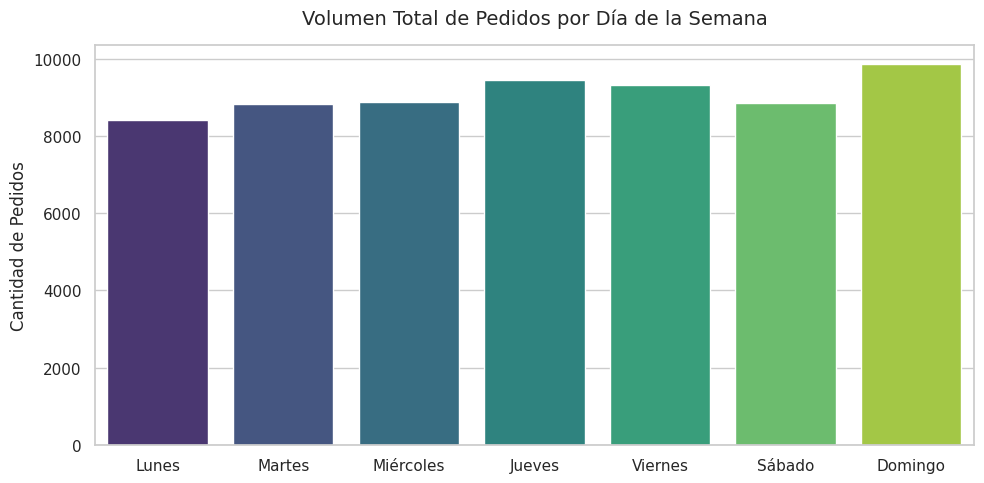

In [17]:
# GRÁFICO 1: Volumen de pedidos por Día de la Semana
# ==============================================================================
plt.figure(figsize=(10, 5))

# countplot para contar pedidos por día
ax1 = sns.countplot(data=df, x='day_of_week', palette='viridis')

# Etiquetas profesionales en lugar de números (0=Lunes, 6=Domingo)
dias_semana = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
plt.title('Volumen Total de Pedidos por Día de la Semana', fontsize=14, pad=15)
plt.xticks(ticks=range(7), labels=dias_semana)
plt.xlabel('')
plt.ylabel('Cantidad de Pedidos', fontsize=12)

plt.tight_layout()
plt.show()

El gráfico de barras de pedidos promedio por día de la semana muestra una distribución notablemente plana.

Interpretación de Negocio: A diferencia del ETA o la Saturación (que sí suben el fin de semana), el volumen bruto de pedidos no presenta variaciones extremas entre un lunes y un domingo.

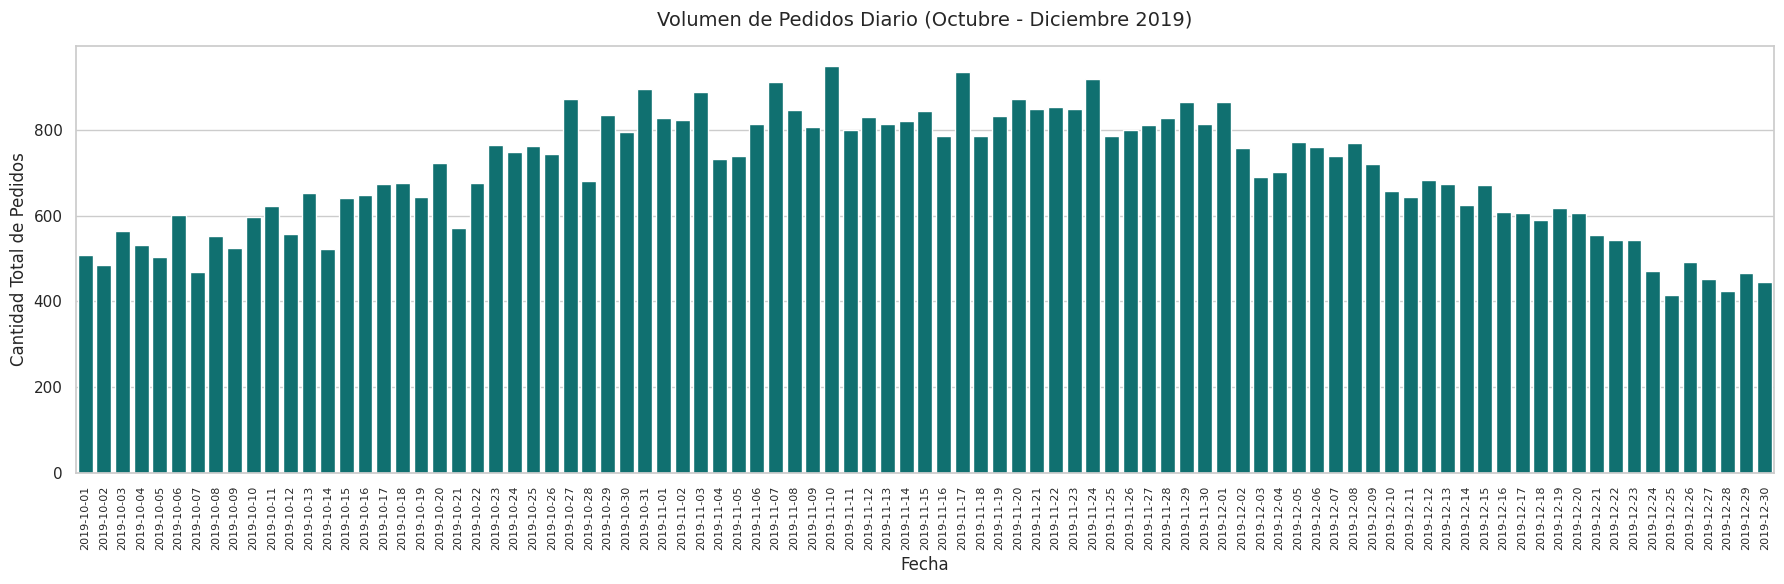

In [18]:
# 1. Extraer solo la fecha (año-mes-día) descartando la hora
df['date'] = df['activation_time_local'].dt.date

# 2. Agrupar y contar la cantidad de pedidos por cada día exacto
pedidos_por_dia = df.groupby('date').size().reset_index(name='cantidad_pedidos')

# 3. Crear el gráfico de barras (Barplot)
plt.figure(figsize=(18, 6)) # Hacemos la figura un poco más ancha para acomodar los 90 días

# Utilizamos color='teal' para mantener tu paleta, o puedes usar palette='viridis' si prefieres gradiente
sns.barplot(data=pedidos_por_dia, x='date', y='cantidad_pedidos', color='teal')

plt.title('Volumen de Pedidos Diario (Octubre - Diciembre 2019)', fontsize=14, pad=15)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Cantidad Total de Pedidos', fontsize=12)

# Rotar las fechas del eje X a 90 grados y reducir un poco la fuente para que quepan bien
plt.xticks(rotation=90, fontsize=8)

plt.tight_layout()
plt.show()

Análisis de Serie Temporal: El Impacto de París 2019
La línea de tiempo revela dos movimientos críticos en el último trimestre de 2019:

Noviembre (Alza Estacional): Se observa un incremento sostenido en el volumen. Esto se atribuye al factor climático; el cambio de estación hacia el invierno en París suele incentivar el consumo en plataformas de delivery debido a la bajada de temperaturas y al aumento de lluvias, reduciendo el desplazamiento de los clientes a tiendas físicas.

Diciembre (Shock Exógeno por Huelgas): Se identifica una caída abrupta a partir del 5 de diciembre de 2019. Este dato coincide con el inicio de las huelgas generales de transporte en Francia.

Impacto en los Datos: Las protestas masivas paralizaron gran parte de la movilidad en París. Para Glovo, esto representó no solo una caída en la demanda, sino una dificultad extrema para que los repartidores pudieran circular, obligando a cerrar zonas de entrega o restringir el servicio.

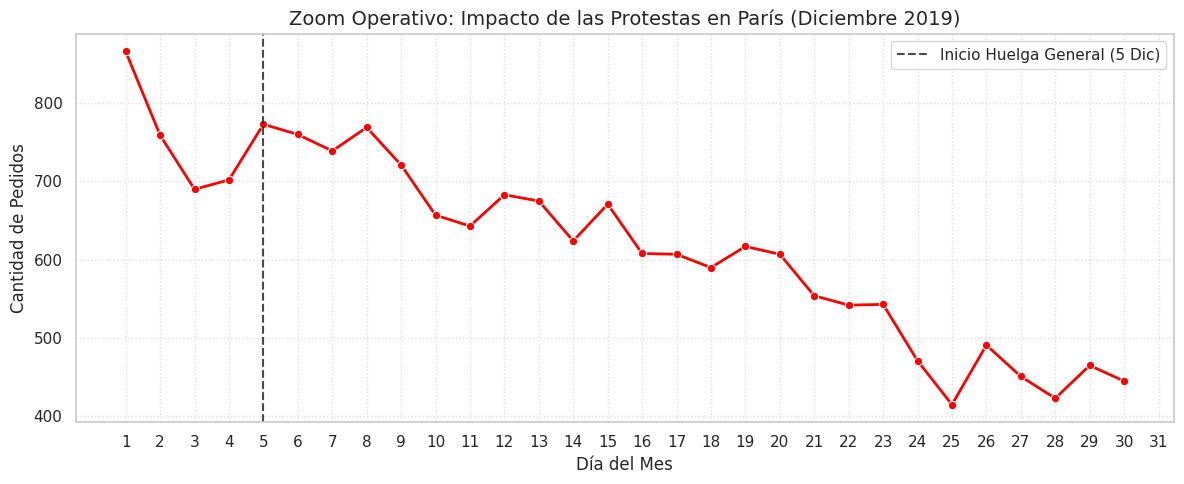

In [19]:
# 1. Filtrar los datos exclusivamente para diciembre de 2019
df_dec = df[(df['activation_time_local'].dt.year == 2019) &
            (df['activation_time_local'].dt.month == 12)].copy()

# 2. Agrupar por día para contar el volumen de pedidos
daily_orders_dec = df_dec.groupby(df_dec['activation_time_local'].dt.day)['order_id'].count()

# 3. Visualización
plt.figure(figsize=(12, 5))
sns.lineplot(x=daily_orders_dec.index, y=daily_orders_dec.values, marker='o', color='red', linewidth=2)

# Añadir una línea vertical justo el 5 de diciembre (Inicio de la huelga)
plt.axvline(x=5, color='black', linestyle='--', alpha=0.7, label='Inicio Huelga General (5 Dic)')

plt.title('Zoom Operativo: Impacto de las Protestas en París (Diciembre 2019)', fontsize=14)
plt.xlabel('Día del Mes', fontsize=12)
plt.ylabel('Cantidad de Pedidos', fontsize=12)
plt.xticks(range(1, 32))
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

/tmp/ipykernel_66200/1818695749.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='hour_of_day', palette='Blues_r')


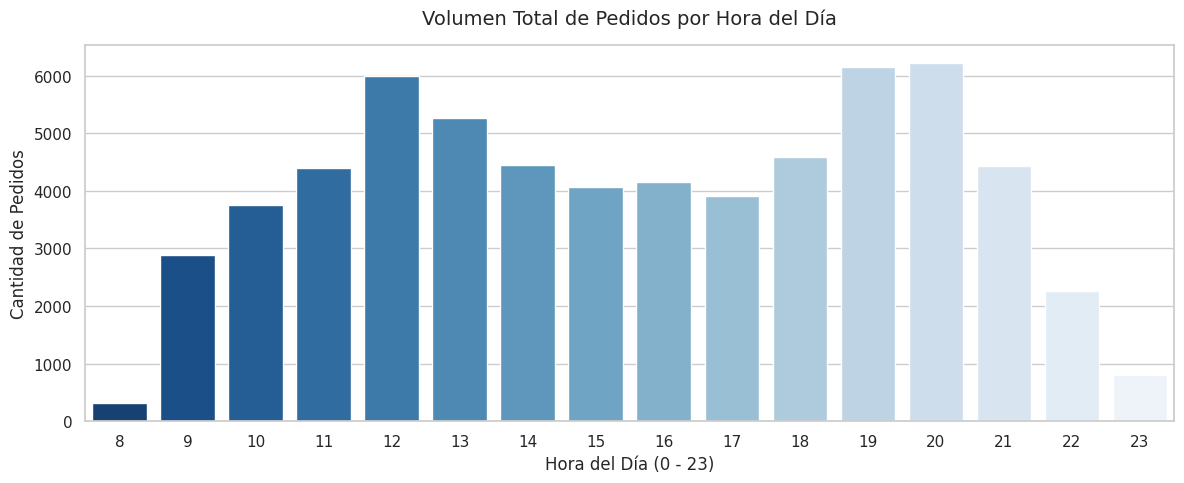

In [20]:
# Configurar el estilo visual
sns.set_theme(style="whitegrid")

# Gráfico: Cantidad total de pedidos por hora del día
plt.figure(figsize=(12, 5))

# countplot cuenta automáticamente cuántas veces aparece cada hora en el dataset
sns.countplot(data=df, x='hour_of_day', palette='Blues_r')

plt.title('Volumen Total de Pedidos por Hora del Día', fontsize=14, pad=15)
plt.xlabel('Hora del Día (0 - 23)', fontsize=12)
plt.ylabel('Cantidad de Pedidos', fontsize=12)

# Aseguramos que se muestren todas las horas en el eje X
# Nota: Si en tus datos no hay pedidos de madrugada (ej. 3 AM o 4 AM),
# Seaborn solo mostrará las horas con datos.
plt.tight_layout()
plt.show()

Con justa razon los horarios que hay mas volumen de pedidos son en los horarios de almuerzo y cena

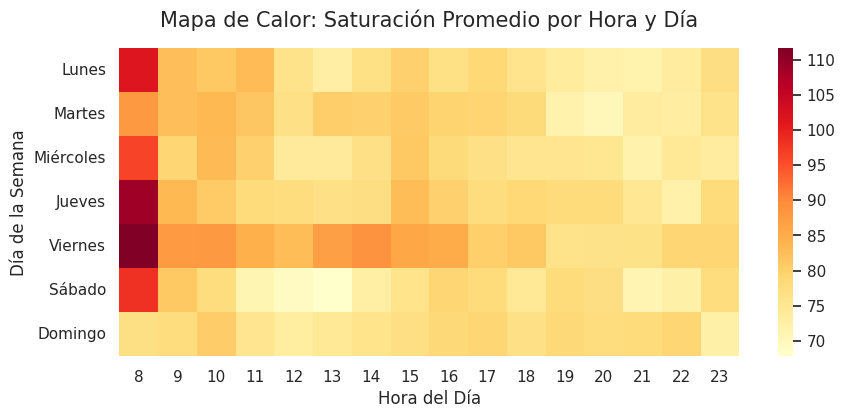

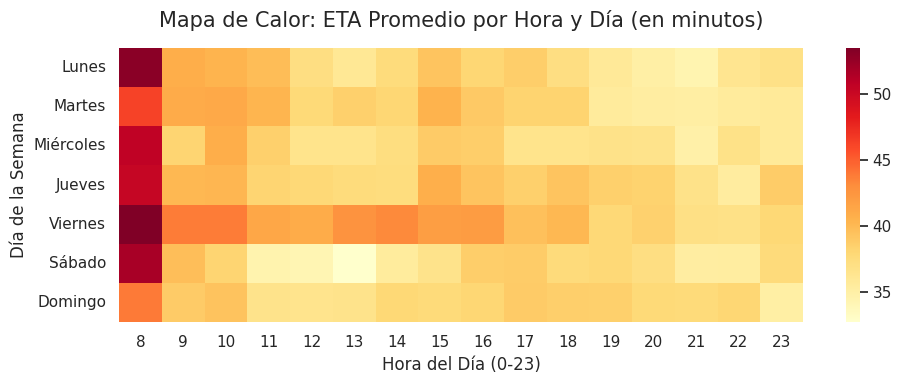

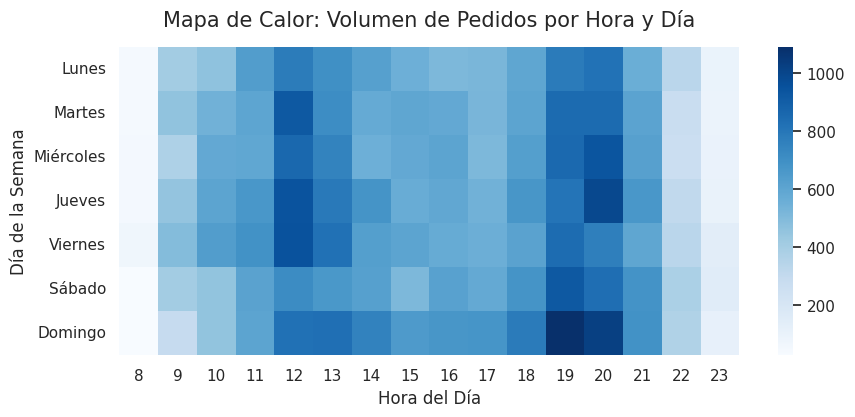

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Preparar los datos (Asegúrate de tener hour_of_day y day_of_week)
dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

# Crear tabla pivote para Saturación (Promedio)
pivot_saturacion = df.pivot_table(index='day_of_week', columns='hour_of_day', values='saturation', aggfunc='mean')

# Crear tabla pivote para Volumen (Conteo de pedidos)
pivot_volumen = df.pivot_table(index='day_of_week', columns='hour_of_day', values='order_id', aggfunc='count')

# --- GRÁFICO 1: MAPA DE CALOR DE SATURACIÓN ---
plt.figure(figsize=(10, 4))
sns.heatmap(pivot_saturacion, cmap='YlOrRd', annot=False, yticklabels=dias)
plt.title('Mapa de Calor: Saturación Promedio por Hora y Día', fontsize=15, pad=15)
plt.xlabel('Hora del Día', fontsize=12)
plt.ylabel('Día de la Semana', fontsize=12)
plt.show()

# 1. Crear la tabla pivote para el ETA Promedio
pivot_eta = df.pivot_table(index='day_of_week',
                           columns='hour_of_day',
                           values='delivery_time_minutes',
                           aggfunc='mean')

# 2. Configuración del gráfico
plt.figure(figsize=(10, 4))
dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

sns.heatmap(pivot_eta, cmap='YlOrRd', annot=False, yticklabels=dias)

plt.title('Mapa de Calor: ETA Promedio por Hora y Día (en minutos)', fontsize=15, pad=15)
plt.xlabel('Hora del Día (0-23)', fontsize=12)
plt.ylabel('Día de la Semana', fontsize=12)
plt.tight_layout()
plt.show()

# --- GRÁFICO 2: MAPA DE CALOR DE VOLUMEN DE PEDIDOS ---
plt.figure(figsize=(10, 4))
sns.heatmap(pivot_volumen, cmap='Blues', annot=False, yticklabels=dias)
plt.title('Mapa de Calor: Volumen de Pedidos por Hora y Día', fontsize=15, pad=15)
plt.xlabel('Hora del Día', fontsize=12)
plt.ylabel('Día de la Semana', fontsize=12)
plt.show()


## Saturación, Volumen y ETA

Al cruzar los tres mapas de calor, identificamos una jerarquía de impacto que es fundamental para el diseño del modelo predictivo:
1. La Correlación Crítica: Saturación $\rightarrow$ ETALa inspección visual confirma que el mapa de Saturación y el de ETA Medio son casi "espejos".


      *   Interpretación: La saturación es el predictor más fiable del tiempo de entrega. Cuando el ratio de pedidos por repartidor disponible se desequilibra, el sistema pierde capacidad de reacción y el ETA se dispara inmediatamente, independientemente de si el volumen total de pedidos es alto o bajo.

2. La Paradoja del Volumen: las horas de mayor volumen (picos azules oscuros) no siempre se traducen en un ETA más alto.

      *   ¿Por qué ocurre esto?: Durante las horas punta previstas (como la cena), Glovo despliega su máxima capacidad de flota. Si hay 1.000 pedidos pero tienes 1.100 repartidores en calle, el sistema fluye.

      *   El Peligro de la Saturación: El ETA sube cuando la saturación es alta, lo cual a veces ocurre en horas de volumen moderado pero con escasez de repartidores (como en el cambio de turno de la tarde o bajo condiciones climáticas adversas)










# FEATURE ENGINEERING

## Eliminar las columnas irrelevantes

Limpieza de Dimensionalidad y Reducción de Ruido
Para optimizar el rendimiento del modelo y evitar el sobreajuste (overfitting), se han eliminado aquellas variables que no aportan valor predictivo o que contienen información redundante/irrelevante para el cálculo del ETA:

In [22]:
df = df.drop(["order_id","customer_id","bad_rating_reason","rating","description","store_address_id","store_name"], axis=1)

## Variables Temporales

Aunque estas variables se utilizaron preliminarmente en el EDA para entender la estacionalidad, se integran formalmente como características del modelo para capturar los ciclos de demanda:


*   delivery_time_minutes: Definida como nuestra variable objetivo (Target). Representa el tiempo total transcurrido desde la activación hasta la entrega final.

*   hour_of_day: Variable clave para capturar la ciclicidad diaria (picos de almuerzo y cena).
*   day_of_week: Permite al modelo distinguir entre el comportamiento operativo de los días laborables y el aumento de saturación típico del fin de semana.

*   date: Utilizada para el cruce con calendarios externos (festivos) y para identificar periodos de anomalías sociales, como las huelgas de París.



### Tratamiento de Outliers


El método de Tukey es una técnica estadística robusta que no asume una distribución normal de los datos. Es ideal para el tiempo de entrega, ya que los datos como vimos anteriormente tienen una "cola larga" (pedidos que tardan mucho por problemas puntuales).1. Fundamento MatemáticoCalculamos el Rango Intercuartílico ($IQR$), que representa el 50% central de nuestros datos, para definir los umbrales de limpieza:$$IQR = Q3 - Q1$$$$Límite Superior = Q3 + 1.5 \times IQR$$$$Límite Inferior = Q1 - 1.5 \times IQR$$

In [23]:
# 1. Calcular Cuartiles y IQR
Q1 = df['delivery_time_minutes'].quantile(0.25)
Q3 = df['delivery_time_minutes'].quantile(0.75)
IQR = Q3 - Q1

# 2. Definir límites
limite_superior = Q3 + 1.5 * IQR
limite_inferior_estadistico = Q1 - 1.5 * IQR
limite_inferior_operativo = 5  # Nuestro umbral de integridad

print(f"Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
print(f"Límite Superior (Tukey): {limite_superior:.2f} minutos")

# 3. Aplicar el filtro
df_clean = df[(df['delivery_time_minutes'] >= limite_inferior_operativo) &
              (df['delivery_time_minutes'] <= limite_superior)].copy()

# 4. Reporte de limpieza
eliminados = len(df) - len(df_clean)
print(f"Registros eliminados: {eliminados} ({ (eliminados/len(df))*100 :.2f}%)")

Q1: 27.40 | Q3: 45.33 | IQR: 17.93
Límite Superior (Tukey): 72.23 minutos
Registros eliminados: 2413 (3.79%)


### Transformar en categorica (ejercicio de clasificacion)

In [24]:
bins = [0, 25, 40, 60, df_clean['delivery_time_minutes'].max()]
labels = ['Fast (<25 min)', 'Normal (25-40 min)', 'Slow (40-60 min)', 'Very Slow (>60 min)']

df_clean['delivery_time_ranges'] = pd.cut(df_clean['delivery_time_minutes'], bins=bins, labels=labels, right=False)

print("The 'delivery_time_ranges' column has been created with the following ranges:")
print(df_clean['delivery_time_ranges'].value_counts())

print("\nAnd its data type is:")
df_clean['delivery_time_ranges'].info()

df_clean.drop("delivery_time_minutes", axis=1)

The 'delivery_time_ranges' column has been created with the following ranges:
delivery_time_ranges
Normal (25-40 min)     29225
Slow (40-60 min)       17455
Fast (<25 min)         11307
Very Slow (>60 min)     3243
Name: count, dtype: int64

And its data type is:
<class 'pandas.core.series.Series'>
Index: 61233 entries, 0 to 63645
Series name: delivery_time_ranges
Non-Null Count  Dtype   
--------------  -----   
61230 non-null  category
dtypes: category(1)
memory usage: 538.4 KB


,courier_id,vertical,gtv,delivery_fee,activation_time_local,courier_started_order_local,pickup_time_local,delivery_time_local,tranport_type,pickup_latitude,pickup_longitude,delivery_latitude,delivery_longitude,saturation,hour_of_day,day_of_week,date,delivery_time_ranges
0,441.0,WALL - Partner,19.97,4.9,2019-10-01 09:21:34,2019-10-01 09:19:06.342,2019-10-01 09:34:55.904,2019-10-01 09:50:02,MOTORBIKE,48.861046,2.275441,48.855068,2.283378,66,9,1,2019-10-01,Normal (25-40 min)
1,239.0,WALL - NonPartner,10.50,4.9,2019-10-01 09:18:30,2019-10-01 09:28:04.560,2019-10-01 09:36:02.133,2019-10-01 09:47:39,BICYCLE,48.871578,2.304495,48.867017,2.292787,40,9,1,2019-10-01,Normal (25-40 min)
2,351.0,WALL - NonPartner,10.35,4.9,2019-10-01 15:04:50,2019-10-01 15:04:28.032,2019-10-01 15:25:37.131,2019-10-01 15:34:52,MOTORBIKE,48.855461,2.360776,48.866713,2.364773,29,15,1,2019-10-01,Normal (25-40 min)
3,391.0,COURIER,6.60,6.6,2019-10-02 10:08:38,2019-10-02 10:11:26.078,2019-10-02 10:30:24.559,2019-10-02 10:50:13,MOTORBIKE,48.859665,2.285694,48.884335,2.259989,54,10,2,2019-10-02,Slow (40-60 min)
4,263.0,WALL - Partner,13.10,3.9,2019-10-02 12:12:09,2019-10-02 12:10:54.226,2019-10-02 12:31:21.010,2019-10-02 12:38:04,MOTORBIKE,48.863417,2.361240,48.868087,2.371050,77,12,2,2019-10-02,Normal (25-40 min)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63641,92.0,WALL - NonPartner,30.30,6.9,2019-11-23 10:28:51,2019-11-23 10:38:12.088,2019-11-23 11:04:19.883,2019-11-23 11:20:22,MOTORBIKE,48.844928,2.237055,48.819739,2.257546,96,10,5,2019-11-23,Slow (40-60 min)
63642,97.0,WALL - Partner,21.90,3.9,2019-10-02 12:00:35,2019-10-02 12:02:50.366,2019-10-02 12:12:21.561,2019-10-02 12:37:06,MOTORBIKE,48.878383,2.285877,48.892718,2.238183,103,12,2,2019-10-02,Normal (25-40 min)
63643,59.0,COURIER,11.90,11.9,2019-12-25 13:39:32,2019-12-25 13:36:20.396,2019-12-25 13:49:32.407,2019-12-25 14:05:28,BICYCLE,48.865610,2.342366,48.880040,2.332157,48,13,2,2019-12-25,Normal (25-40 min)
63644,402.0,COURIER,12.90,12.9,2019-12-06 13:02:10,2019-12-06 13:23:13.630,2019-12-06 13:30:59.134,2019-12-06 14:03:18,BICYCLE,48.874409,2.332547,48.886671,2.284347,109,13,4,2019-12-06,Very Slow (>60 min)


## Distancia


A diferencia de la distancia euclídea (línea recta en un plano), la Fórmula de Haversine tiene en cuenta que la Tierra es una esfera. Esto es crítico cuando trabajamos con coordenadas GPS (latitud y longitud), ya que la distancia entre grados de longitud varía según la latitud. Utilizar esta fórmula garantiza que los kilómetros calculados sean precisos para la operativa en una ciudad como París.Implementación VectorizadaEl código utiliza vectorización con NumPy. En lugar de calcular la distancia fila por fila con un bucle (proceso lento), la función procesa todas las coordenadas simultáneamente como vectores.



*   Eficiencia: Esto reduce el tiempo de ejecución de segundos a milisegundos, permitiendo que el pre-procesamiento sea escalable para datasets de gran volumen.
*   Radio Terrestre: Se utiliza el valor estándar de $6.371$ km para obtener el resultado final en kilómetros.




In [25]:
def haversine_vectorized(lat1, lon1, lat2, lon2):
    # Radio de la Tierra en kilómetros
    R = 6371.0

    # Convertir todas las coordenadas de grados a radianes
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    # Calcular las diferencias
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Aplicar la fórmula matemática
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))

    # Multiplicar por el radio para obtener la distancia final en kilómetros
    return R * c

# Crear la nueva columna en el dataset
df_clean['distance_km'] = haversine_vectorized(
    df['pickup_latitude'],
    df['pickup_longitude'],
    df['delivery_latitude'],
    df['delivery_longitude']
)

# Visualizar las primeras filas para comprobar que se ha calculado correctamente
print(df_clean[['pickup_latitude', 'pickup_longitude', 'delivery_latitude', 'delivery_longitude', 'distance_km']].head())

   pickup_latitude  pickup_longitude  delivery_latitude  delivery_longitude  \
0        48.861046          2.275441          48.855068            2.283378   
1        48.871578          2.304495          48.867017            2.292787   
2        48.855461          2.360776          48.866713            2.364773   
3        48.859665          2.285694          48.884335            2.259989   
4        48.863417          2.361240          48.868087            2.371050   

   distance_km  
0     0.882526  
1     0.995245  
2     1.284852  
3     3.325588  
4     0.885714  


## Store ID

Las variables de store id (store name y store coorditanes ID) estan incompletas. Para identificar las tiendas individualmente, podemos crear una variable tipo object que sea el resultado de concatenar pickup_latitude y pickup_longitud (las coordenadas son lo suficientemente precisas -6 puntos decimales- para identificar un cuadrado de 11m, mas que suficiente para una tienda)

In [26]:
df_clean['store'] = df_clean['pickup_latitude'].astype(str) + '_' + df_clean['pickup_longitude'].astype(str)

In [27]:
df_clean['store'].head()

,store
0,48.8610457_2.2754414999999426
1,48.8715778_2.3044947
2,48.8554611_2.3607756
3,48.8596646_2.2856938
4,48.8634168_2.36124


## Areas

Actualmente las coordenadas de pickup y dropoff son demasiado precisas para que el modelo aprenda patrones por área. Asi que, hemos decidido cortar las variables de latitudes y longitudes a 2 decimales (da una área de 1kmx1km, en lugar de la actual de tan solo 10cm).

In [28]:
import numpy as np

df_clean['pickup_latitude'] = np.floor(df_clean['pickup_latitude'] * 100) / 100
df_clean['pickup_longitude'] = np.floor(df_clean['pickup_longitude'] * 100) / 100
df_clean['delivery_latitude'] = np.floor(df_clean['delivery_latitude'] * 100) / 100
df_clean['delivery_longitude'] = np.floor(df_clean['delivery_longitude'] * 100) / 100

In [29]:
df_clean[['pickup_latitude',"pickup_longitude","delivery_latitude","delivery_longitude"]].describe()

,pickup_latitude,pickup_longitude,delivery_latitude,delivery_longitude
count,61233.000000,61233.000000,61233.000000,61233.000000
mean,48.859083,2.316568,48.859151,2.313159
std,0.018052,0.037546,0.020313,0.040596
min,48.800000,2.220000,48.790000,2.210000
25%,48.850000,2.280000,48.850000,2.280000
50%,48.860000,2.320000,48.860000,2.310000
75%,48.870000,2.340000,48.870000,2.340000
max,48.910000,2.430000,48.920000,2.440000


# Modelos

## Consolidación del Feature Set y Codificación Final

En esta etapa de cierre, transformamos el dataset procesado en una matriz numérica optimizada para el algoritmo XGBoost. Los pasos realizados aseguran la integridad de los datos y la compatibilidad técnica del modelo:



*   Selección Estratégica de Predictores: Se han filtrado las variables para mantener únicamente aquellas con relevancia operativa confirmada durante el EDA (distancia, saturación, temporalidad y geolocalización). El uso del método .dropna() garantiza que el modelo trabaje exclusivamente con registros completos, eliminando cualquier inconsistencia remanente.

*   Transformación de Variables Categóricas (One-Hot Encoding): Dado que los algoritmos de gradiente descendente requieren entradas numéricas, las variables cualitativas (tranport_type y vertical) se han codificado mediante columnas binarias. Se ha aplicado el parámetro drop_first=True para mitigar la trampa de la variable dummy, eliminando la redundancia y evitando problemas de multicolinealidad que podrían desestabilizar los pesos del modelo.
*   Normalización de Sintaxis para XGBoost: Se ha realizado una limpieza de los nombres de las columnas para sustituir espacios y caracteres especiales por guiones bajos. Este paso es crítico para asegurar la compatibilidad con la implementación de XGBoost, evitando errores de análisis sintáctico durante el entrenamiento y facilitando la correcta visualización de la importancia de las variables (Feature Importance).




In [30]:
df_clean.columns

Index(['courier_id', 'vertical', 'gtv', 'delivery_fee',
       'activation_time_local', 'courier_started_order_local',
       'pickup_time_local', 'delivery_time_local', 'tranport_type',
       'pickup_latitude', 'pickup_longitude', 'delivery_latitude',
       'delivery_longitude', 'saturation', 'delivery_time_minutes',
       'hour_of_day', 'day_of_week', 'date', 'delivery_time_ranges',
       'distance_km', 'store'],
      dtype='object')

In [41]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61233 entries, 0 to 63645
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   courier_id                   61233 non-null  float64       
 1   vertical                     61233 non-null  object        
 2   gtv                          61233 non-null  float64       
 3   delivery_fee                 61233 non-null  float64       
 4   activation_time_local        61233 non-null  datetime64[ns]
 5   courier_started_order_local  61230 non-null  datetime64[ns]
 6   pickup_time_local            61233 non-null  datetime64[ns]
 7   delivery_time_local          61233 non-null  datetime64[ns]
 8   tranport_type                61233 non-null  object        
 9   pickup_latitude              61233 non-null  float64       
 10  pickup_longitude             61233 non-null  float64       
 11  delivery_latitude            61233 non-null  f

In [32]:
# import pandas as pd

columnas_modelo = ["courier_id",'store','delivery_time_ranges', 'distance_km', 'gtv', 'delivery_fee', 'saturation',
    'hour_of_day', 'day_of_week',
    'pickup_latitude', 'pickup_longitude', 'delivery_latitude', 'delivery_longitude',
    'tranport_type', 'vertical'
]

# 2. Creamos el dataset final (usando df_clean que ya tiene el filtro de Tukey)
# El .dropna() es importante por si store_address_id u otras tenían nulos
df_final_1 = df_clean[columnas_modelo].dropna().copy()

# 3. ONE-HOT ENCODING (Variables Dummy)
# Esto convertirá 'tranport_type' y 'vertical' en números
df_final_1 = pd.get_dummies(df_final_1, columns=['tranport_type', 'vertical',"store"], drop_first=True)

# 4. NORMALIZACIÓN DE NOMBRES PARA XGBOOST
# Reemplazamos espacios y guiones para evitar errores en el algoritmo
df_final_1.columns = [c.replace(' ', '_').replace('-', '_') for c in df_final_1.columns]

print(f"Total de registros: {len(df_final_1)}")
print(f"Variables para el modelo ({len(df_final_1.columns)}):")
print(df_final_1.columns.tolist())

Total de registros: 61230
Variables para el modelo (6337):
['courier_id', 'delivery_time_ranges', 'distance_km', 'gtv', 'delivery_fee', 'saturation', 'hour_of_day', 'day_of_week', 'pickup_latitude', 'pickup_longitude', 'delivery_latitude', 'delivery_longitude', 'tranport_type_CAR', 'tranport_type_MOTORBIKE', 'tranport_type_WALKER', 'vertical_WALL___NonPartner', 'vertical_WALL___Partner', 'store_48.8040272634597_2.3670799657702446', 'store_48.8068175_2.2856272', 'store_48.8068175_2.2856272000000217', 'store_48.80918_2.2981775', 'store_48.80921300000001_2.3628926', 'store_48.8095372_2.3634748', 'store_48.8101701_2.3306388', 'store_48.81086939999999_2.3176521', 'store_48.81096659999999_2.3367785000000367', 'store_48.81107369999999_2.3044039', 'store_48.8125118_2.3263494', 'store_48.8126961_2.3223894', 'store_48.81337019999999_2.3211836', 'store_48.813424_2.2856234', 'store_48.81353487088106_2.318066284060478', 'store_48.8139387_2.322124', 'store_48.8139552_2.3223688', 'store_48.8155671_2.

In [33]:
df_final_1.columns

Index(['courier_id', 'delivery_time_ranges', 'distance_km', 'gtv',
       'delivery_fee', 'saturation', 'hour_of_day', 'day_of_week',
       'pickup_latitude', 'pickup_longitude',
       ...
       'store_48.9076773_2.2684164', 'store_48.9078963_2.3064186',
       'store_48.9123643_2.3449849', 'store_48.9132805_2.3286782',
       'store_48.9137707_2.3438515', 'store_48.9139791_2.3460991',
       'store_48.9140598_2.3414753', 'store_48.9143262_2.3249456',
       'store_48.9146211_2.3379836', 'store_48.9161039_2.3436464'],
      dtype='object', length=6337)

In [34]:
df_final_1=df_clean.copy()

## XGBoost


Para la etapa final del modelado, implementamos XGBoost (Extreme Gradient Boosting) utilizando el conjunto de variables optimizado. A diferencia del Random Forest, XGBoost aplica una estrategia de aprendizaje secuencial donde cada iteración busca minimizar el residuo (error) de la etapa anterior mediante el cálculo de gradientes.

In [35]:
from sklearn.model_selection import train_test_split

# 1. Separar la variable objetivo (y) de las predictoras (X)
X = df_final_1.drop('delivery_time_ranges', axis=1)
y = df_final_1['delivery_time_ranges']

# 2. División 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Muestras de entrenamiento: {X_train.shape[0]}")
print(f"Muestras de prueba: {X_test.shape[0]}")

Muestras de entrenamiento: 48986
Muestras de prueba: 12247


## Optimización de Hiperparámetros (Hyperparameter Tuning)
Utilizaremos RandomizedSearchCV para explorar diferentes configuraciones de profundidad, tasa de aprendizaje y regularización.

# Multimodal

In [36]:
df_final_2=df_clean.copy()

In [37]:
df_final_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61233 entries, 0 to 63645
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   courier_id                   61233 non-null  float64       
 1   vertical                     61233 non-null  object        
 2   gtv                          61233 non-null  float64       
 3   delivery_fee                 61233 non-null  float64       
 4   activation_time_local        61233 non-null  datetime64[ns]
 5   courier_started_order_local  61230 non-null  datetime64[ns]
 6   pickup_time_local            61233 non-null  datetime64[ns]
 7   delivery_time_local          61233 non-null  datetime64[ns]
 8   tranport_type                61233 non-null  object        
 9   pickup_latitude              61233 non-null  float64       
 10  pickup_longitude             61233 non-null  float64       
 11  delivery_latitude            61233 non-null  f

## Target

In [38]:
df_final_2['Pickup_to_delivery'] = (df_clean['delivery_time_local'] - df_clean['pickup_time_local']).dt.total_seconds() / 60
df_final_2['Courier_to_pickup'] = (df_clean['pickup_time_local'] - df['courier_started_order_local']).dt.total_seconds() / 60
df_final_2['Activation_to_courier'] = (df_clean['courier_started_order_local'] - df_clean['activation_time_local']).dt.total_seconds() / 60

In [39]:
columns_to_process = ['Activation_to_courier', 'Courier_to_pickup', 'Pickup_to_delivery']

for col in columns_to_process:
    # Calculate the mean of positive values for the current column
    positive_mean = df_final_2[df_final_2[col] > 0][col].mean()

    # Replace negative values with the calculated positive mean
    # Use .loc to avoid SettingWithCopyWarning
    df_final_2.loc[df_final_2[col] < 0, col] = positive_mean

print("Negative values in 'Activation_to_courier', 'Courier_to_pickup', and 'Pickup_to_delivery' have been replaced with the mean of their positive values.")

# Display descriptive statistics for the modified columns to verify the changes
print(df_final_2[columns_to_process].describe())

Negative values in 'Activation_to_courier', 'Courier_to_pickup', and 'Pickup_to_delivery' have been replaced with the mean of their positive values.
       Activation_to_courier  Courier_to_pickup  Pickup_to_delivery
count           61230.000000       61230.000000        61233.000000
mean                5.905716          15.382018           17.154738
std                 5.664599           8.320187            8.820997
min                 0.001067           0.008883            0.012650
25%                 2.399525           9.564496           10.894400
50%                 5.905716          13.943142           15.598683
75%                 5.905716          19.617800           21.765200
max                66.689650          94.210000           70.883600


In [40]:
df_final_2[["Activation_to_courier",'Courier_to_pickup','Activation_to_courier']].describe()

,Activation_to_courier,Courier_to_pickup,Activation_to_courier
count,61230.000000,61230.000000,61230.000000
mean,5.905716,15.382018,5.905716
std,5.664599,8.320187,5.664599
min,0.001067,0.008883,0.001067
25%,2.399525,9.564496,2.399525
50%,5.905716,13.943142,5.905716
75%,5.905716,19.617800,5.905716
max,66.689650,94.210000,66.689650
